In [5]:
import pandas as pd

# 1. Load the training and testing datasets
train_df = pd.read_csv("C:/Users/Simon/Downloads/titanic/train.csv")
test_df = pd.read_csv("C:/Users/Simon/Downloads/titanic/test.csv")

In [7]:
# 2. Look at the first 5 rows to see what the raw data looks like
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
# 3. Check the structure and data types in the training dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
#Returns the summary statistics of both categorical and numerical columns
train_df.describe(include="all") 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [16]:
#Returns all the missing value in each column
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We have three columns with missing data, and we should use a completely different strategy for each one.
1. The Embarked Column (2 missing) - Since only 2 passengers out of 891 are missing their embarkation port, the statistical impact is basically zero. The standard practice here is mode imputation, we just fill those two empty spots with the most common port (mode).

In [22]:
# Find the most frequent port which is 'S'
most_common_port = train_df['Embarked'].mode()[0]
print(most_common_port)

# Fill the missing values
train_df['Embarked'] = train_df['Embarked'].fillna(most_common_port)

S


2. The Cabin Column (687 missing)
Here, ~77% of the data is missing. You cannot accurately guess a specific cabin number for that many people. First-class passengers were much more likely to have their cabin number recorded than third-class passengers. Let's create a new feature that just tracks whether they had a recorded cabin or not.

In [25]:
# Create a new categorical column: 1 if they have a cabin, 0 if it's missing (NaN)
train_df['Has_Cabin'] = train_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Now we can safely drop the original Cabin column
train_df = train_df.drop('Cabin', axis=1)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


3. The Age Column (177 missing)
Age is a massive predictor of survival, so we can't drop the column. We also can't just drop the 177 rows, or we lose valuable data. Look at the Name column. Everyone has a title (Mr., Mrs., Master, Miss). A "Master" is a young boy, while a "Mrs." is a married woman. We can extract these titles and fill the missing ages with the median age of that specific title group.

In [26]:
# Step A: Extract the Title from the Name column using a regular expression
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Step B: Let's see the median age for each title just to prove it works
print("Median age by title:")
print(train_df.groupby('Title')['Age'].median())

# Step C: Fill the missing ages using the median age of their specific Title
train_df['Age'] = train_df['Age'].fillna(train_df.groupby('Title')['Age'].transform('median'))

# Step D: We don't need the complex Name column anymore
train_df = train_df.drop('Name', axis=1)

Median age by title:
Title
Capt        70.0
Col         58.0
Countess    33.0
Don         40.0
Dr          46.5
Jonkheer    38.0
Lady        48.0
Major       48.5
Master       3.5
Miss        21.0
Mlle        24.0
Mme         24.0
Mr          30.0
Mrs         35.0
Ms          28.0
Rev         46.5
Sir         49.0
Name: Age, dtype: float64


In [27]:
#Check whether the changes have been effected
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,1,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,S,0,Mr


In [28]:
#Checking whether the nulls have been filled
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
Title          0
dtype: int64

Whatever transformations we do to train_df, we must do the exact same things to test_df. Our model will crash later if the test data has missing columns or different features than the training data.

In [29]:
#Checking the nulls in the test dataset
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

We repeat the procedure we did in the training dataset

In [31]:
# Create a new column: 1 if they have a cabin, 0 if it's missing (NaN)
test_df['Has_Cabin'] = test_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Now we can safely drop the original Cabin column
test_df = test_df.drop('Cabin', axis=1)
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0


In [32]:
# Step A: Extract the Title from the Name column using a regular expression
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Step B: Let's see the median age for each title just to prove it works
print("Median age by title:")
print(test_df.groupby('Title')['Age'].median())

# Step C: Fill the missing ages using the median age of their specific Title
test_df['Age'] = test_df['Age'].fillna(train_df.groupby('Title')['Age'].transform('median'))

# Step D: We don't need the complex Name column anymore
test_df = test_df.drop('Name', axis=1)

Median age by title:
Title
Col       50.0
Dona      39.0
Dr        53.0
Master     7.0
Miss      22.0
Mr        28.5
Mrs       36.5
Ms         NaN
Rev       35.5
Name: Age, dtype: float64


In [33]:
# Checking whether the changes have been effected
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title
0,892,3,male,34.5,0,0,330911,7.8292,Q,0,Mr
1,893,3,female,47.0,1,0,363272,7.0000,S,0,Mrs
2,894,2,male,62.0,0,0,240276,9.6875,Q,0,Mr
3,895,3,male,27.0,0,0,315154,8.6625,S,0,Mr
4,896,3,female,22.0,1,1,3101298,12.2875,S,0,Mrs


For the missing Fare column, Ticket prices are directly tied to what class the passenger was traveling in (Pclass). If the missing value belongs to a 3rd class passenger, filling it with the median of the whole ship (which includes 1st class tickets) might overestimate what they paid. Instead, fill it with the median fare of their specific passenger class.

In [35]:
# Fill the missing Fare using the median Fare of that specific Pclass
test_df['Fare'] = test_df['Fare'].fillna(test_df.groupby('Pclass')['Fare'].transform('median'))

In [36]:
# Check whether the missing values have been filled
test_df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
Title          0
dtype: int64

STEP 2: VISUALIZATIONS

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

Text(0, 0.5, 'Number of Passengers')

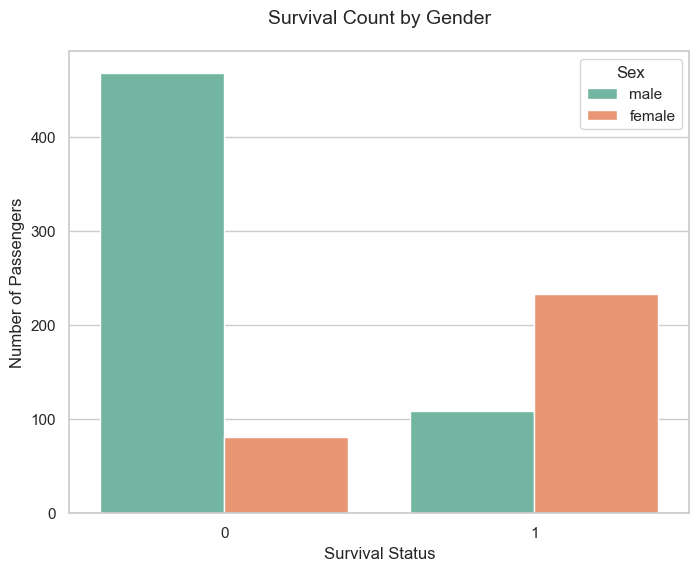

In [40]:
# Plot 1: Survival Count by Gender
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=train_df, 
                   x='Survived', 
                   hue='Sex', 
                   palette='Set2',
                   order=[0, 1])

plt.title('Survival Count by Gender', fontsize=14, pad=20)
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')

Gender (Plot 1): The vast majority of men died, while the majority of women survived. This tells us Sex will be the single most important feature for our model.

C:\Users\Simon\AppData\Local\Temp\ipykernel_18220\4043312747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Pclass', y='Survived', palette='viridis')


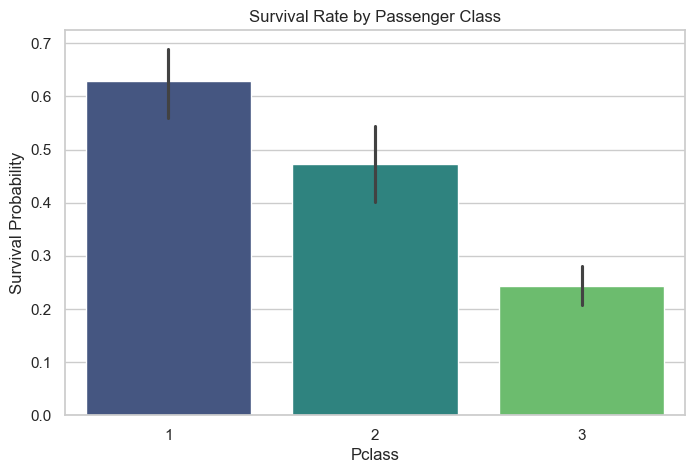

In [41]:
# Plot 2: Survival Rate by Passenger Class
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='Pclass', y='Survived', palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability')
plt.show()

Class (Plot 2): 1st class passengers had roughly a 60%+ chance of survival, while 3rd class was down near 25%. This proves socio-economic status played a huge role.

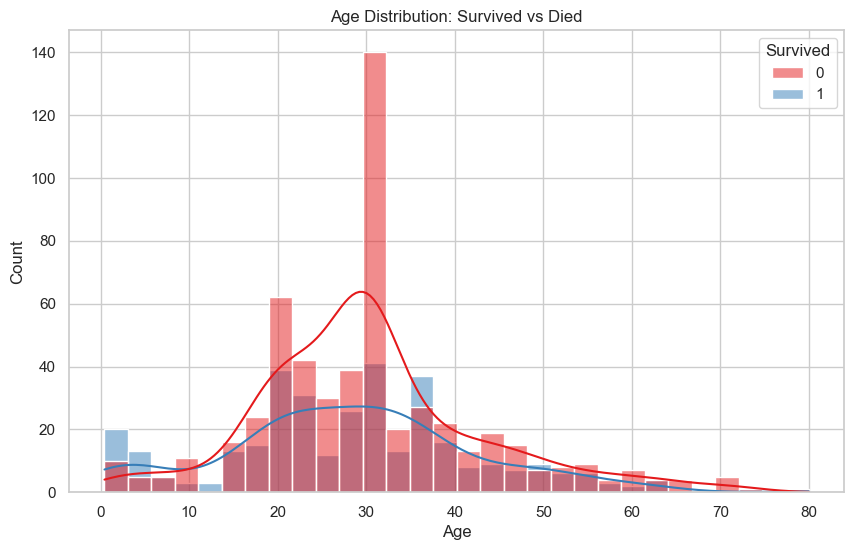

In [42]:
# Plot 3: Age Distribution: Survivors vs Non-Survivors
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=30, palette='Set1')
plt.title('Age Distribution: Survived vs Died')
plt.show()

Age (Plot 3): If you look at the far left of the histogram, you will see a spike in survival for children (ages 0-5). You'll also see that the bulk of casualties were adults between 20 and 30 years old.

Step 3: Feature Engineering & Preprocessing

In [43]:
# 1. Feature Engineering: Family Size
# Combine Siblings/Spouses (SibSp) and Parents/Children (Parch) plus 1 (for the passenger themselves)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

# 2. Drop the noise
# Ticket numbers are too random to be useful without extreme text processing.
# PassengerId is just a row number.
train_df = train_df.drop(['Ticket', 'PassengerId'], axis=1)
test_df = test_df.drop(['Ticket', 'PassengerId'], axis=1)

# 3. Categorical Encoding (Turning Text into Numbers)
# This converts columns like 'Sex' (male/female) into binary columns (Sex_male: 1 or 0)
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'], drop_first=True)

# 4. Final check to ensure all columns are numerical
print(train_df.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Has_Cabin       int64
Title          object
FamilySize      int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


Family Size: Why combine them? Because survival wasn't just about whether you had a brother on board; it was about the size of your group. Small families (2-4 people) actually had a higher survival rate than people traveling completely alone (who had no one to help them) and massive families (who struggled to stay together in the chaos).

One-Hot Encoding (pd.get_dummies): This is standard practice for converting categories. If a passenger boarded at Southampton ('S'), the Embarked_S column becomes a 1, and the other port columns become 0.

(drop_first=True): We added drop_first=True. If a passenger is not male, the model automatically knows they are female. Keeping both a Sex_male and Sex_female column creates redundant data (called multicollinearity), which can confuse certain algorithms.

At this point, our dataset is purely numerical and 100% ready to be fed into a machine learning algorithm.

In [49]:
# Drop the leftover text column from both datasets
train_df = train_df.drop('Title', axis=1, errors='ignore')
test_df = test_df.drop('Title', axis=1, errors='ignore')

# Verify that there are no more "object" (text) columns left
print(train_df.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Has_Cabin       int64
FamilySize      int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


Step 4: Model Selection and Training.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Separate the features (X) from the target/answer key (y)
# We drop 'Survived' from X because that's what we are trying to predict
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# 2. Split our training data into a smaller "train" and "validation" set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Random Forest model
# n_estimators=100 means we are building 100 decision trees
# max_depth=5 stops the trees from getting too complex (prevents overfitting!)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. Train the model (This is where the learning happens)
model.fit(X_train, y_train)

# 5. Make predictions on our 20% validation set
val_predictions = model.predict(X_val)

# 6. Check our initial accuracy
accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 82.68%


Step 5: Evaluation & Feature Importance

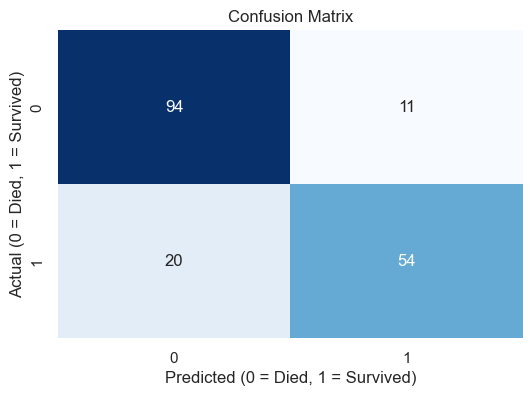

In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. The Confusion Matrix
cm = confusion_matrix(y_val, val_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted (0 = Died, 1 = Survived)')
plt.ylabel('Actual (0 = Died, 1 = Survived)')
plt.show()

The Confusion Matrix: This shows exactly where your 82% came from. The top-left number is people who actually died and your model correctly predicted died (True Negatives). The bottom-right is people who survived and your model correctly predicted survived (True Positives). The other two boxes are your model's mistakes (False Positives and False Negatives).

In [52]:
# 2. The Classification Report (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_val, val_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       105
           1       0.83      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179



The Classification Report: Focus on Recall for Class 1 (Survived). This tells you: Out of everyone who actually survived, what percentage did our model successfully identify? Sometimes a model is great at predicting who died, but terrible at predicting who survived.

C:\Users\Simon\AppData\Local\Temp\ipykernel_18220\1299878165.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='mako')


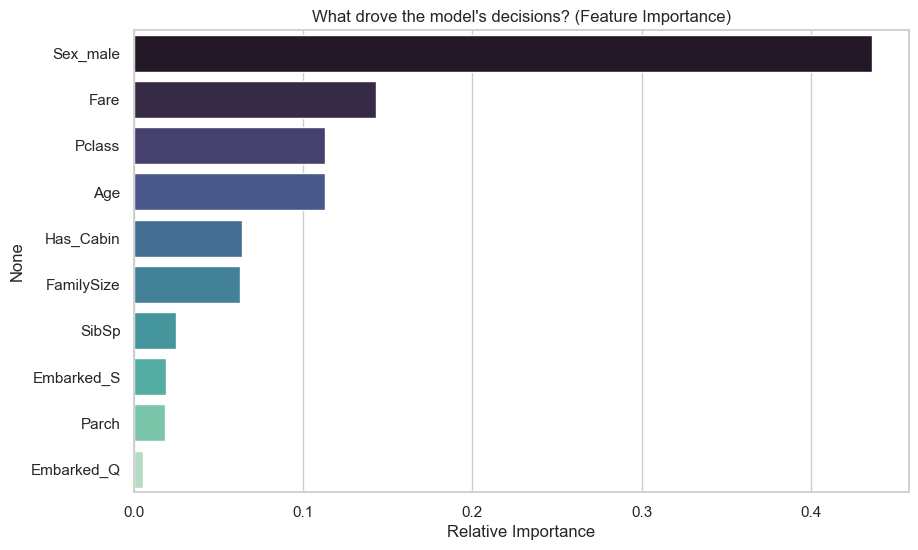

In [55]:
# 3. Feature Importance
importances = model.feature_importances_
features = X.columns
# Sort the features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette='mako')
plt.title('What drove the model\'s decisions? (Feature Importance)')
plt.xlabel('Relative Importance')
plt.show()

Feature Importance: This is usually the most interesting chart for non-technical stakeholders. It ranks what the algorithm cared about most. You will almost certainly see Sex_male, Fare, Age, and Pclass at the very top. This mathematically proves the old maritime rule: "Women, children, and the wealthy first."

In [56]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 1.0/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.1/101.7 MB 3.1 MB/s eta 0:00:33
   - -------------------------------------- 3.1/101.7 MB 3.9 MB/s eta 0:00:26
   -- ------------------------------------- 5.2/101.7 MB 4.7 MB/s eta 0:00:21
   -- ------------------------------------- 5.8/101.7 MB 4.4 MB/s eta 0:00:22
   -- ------------------------------------- 6.0/101.7 MB 4.4 MB/s eta 0:00:22
   -- ------------------------------------- 7.3/101.7 MB 4.4 MB/s eta 0:00:22
   -- ------------------------------------- 7.3/101.7 MB 4.4 MB/s eta 0:00:22
   -- --------

Using GridSearchCV on our Baseline Random Forest, train an XGBoost model, and print a comparative report.

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Quick Data Re-split (Just to ensure clean state)
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# MODEL 1: Baseline Random Forest (What we already did)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

#  Train the model (This is where the learning happens)
model.fit(X_train, y_train)

# Make predictions on our 20% validation set
val_predictions = model.predict(X_val)

# 6. Check our initial accuracy
accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 82.68%


In [60]:
# MODEL 2: Tuned Random Forest (via GridSearchCV)

# Define the dictionary of hyperparameter grids to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Set up the Grid Search with 5-fold cross-validation
# n_jobs=-1 tells Python to use all our computer's CPU cores to speed things up
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Running Grid Search on Random Forest")
rf_grid.fit(X_train, y_train)

# Grab the absolute best-performing version of the model
tuned_rf = rf_grid.best_estimator_
acc_tuned_rf = accuracy_score(y_val, tuned_rf.predict(X_val))

Running Grid Search on Random Forest


In [62]:
# MODEL 3: XGBoost Classifier

# Initialize an Extreme Gradient Boosting model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss' # Suppresses modern warning flags
)

print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
acc_xgb = accuracy_score(y_val, xgb_model.predict(X_val))

Training XGBoost Classifier...


In [68]:
# FINAL REPORT: Compare Results

print("             MODEL COMPARISON           ")
print(f"1. Random Forest Classifier:   {accuracy * 100:.2f}%")
print(f"2. GridSearch Tuned RF:        {acc_tuned_rf * 100:.2f}%")
print(f"3. Extreme Gradient Boosting:  {acc_xgb * 100:.2f}%")

print(f"Best Tuned RF Params: {rf_grid.best_params_}")

             MODEL COMPARISON           
1. Random Forest Classifier:   82.68%
2. GridSearch Tuned RF:        81.56%
3. Extreme Gradient Boosting:  82.12%
Best Tuned RF Params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 10, 'n_estimators': 50}
